In [166]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FuncFormatter


from decimal import ROUND_HALF_UP, Decimal


PATH="/home/vinesnts/Downloads/"

In [167]:
availability = [
    0.866351764378994,
    0.869317920395753,
    0.870680799291791,
    0.871769688998246,
    0.874903828159115,
    0.881897436929954,
    0.884326769558276,
    0.884362511280134,
    0.884645211322218,
    0.885125169215849,
    0.88531149849021,
    0.886357321478188,
    0.886740561713476,
    0.886787204450626,
    0.887104141700209,
    0.888588578859922,
    0.888814678286335,
    0.889659083115741,
    0.88994865475457,
    0.890110782186095,
    0.890216787103947,
    0.890803000833565,
    0.890987362866269,
    0.891048159731811,
    0.892436534041339,
    0.892681174017433,
    0.89403916048859,
    0.896187656570257,
    0.896598980679487,
    0.896774967030332,
    0.898557689740427,
    0.898785694975762,
    0.898868557061042,
    0.90017471723395,
    0.90025006946374,
    0.901010805158592,
    0.901010805158592,
    0.901056262125458,
    0.902216096897919,
    0.902743316379818,
    0.904656216676919,
    0.905108359485409,
    0.905119622045834,
    0.905241173440596,
    0.906036541345033,
    0.906591156523737,
    0.906614785992218,
    0.907984249211756,
    0.910808557932759,
    0.911364267852181,
    0.911586495965328,
    0.912731694958196,
    0.914037775095355,
    0.915254237288136,
    0.916287001450788,
    0.920650279563035,
    0.920800639910446,
    0.921072118054637,
    0.931243879720079,
    0.935829889502902,
]
availability

[0.866351764378994,
 0.869317920395753,
 0.870680799291791,
 0.871769688998246,
 0.874903828159115,
 0.881897436929954,
 0.884326769558276,
 0.884362511280134,
 0.884645211322218,
 0.885125169215849,
 0.88531149849021,
 0.886357321478188,
 0.886740561713476,
 0.886787204450626,
 0.887104141700209,
 0.888588578859922,
 0.888814678286335,
 0.889659083115741,
 0.88994865475457,
 0.890110782186095,
 0.890216787103947,
 0.890803000833565,
 0.890987362866269,
 0.891048159731811,
 0.892436534041339,
 0.892681174017433,
 0.89403916048859,
 0.896187656570257,
 0.896598980679487,
 0.896774967030332,
 0.898557689740427,
 0.898785694975762,
 0.898868557061042,
 0.90017471723395,
 0.90025006946374,
 0.901010805158592,
 0.901010805158592,
 0.901056262125458,
 0.902216096897919,
 0.902743316379818,
 0.904656216676919,
 0.905108359485409,
 0.905119622045834,
 0.905241173440596,
 0.906036541345033,
 0.906591156523737,
 0.906614785992218,
 0.907984249211756,
 0.910808557932759,
 0.911364267852181,
 0.91

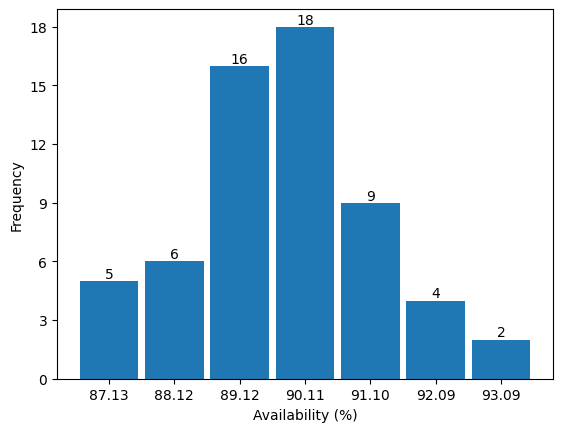

In [168]:

bins = int(math.sqrt(len(availability)))
counts, bins, patches = plt.hist(
    availability,
    bins=bins,
    rwidth=0.9
)

bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Set ticks at bin centers
plt.xticks(bin_centers)

# Round-half-up formatter for bin centers
def format_percent_half_up(x, format="0.00"):
    return (
        (Decimal(str(x)) * Decimal("100"))
        .quantize(Decimal(format), rounding=ROUND_HALF_UP)
    )

plt.gca().set_xticklabels(
    [f"{format_percent_half_up(x)}" for x in bin_centers]
)

plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.gca().yaxis.set_major_locator(MultipleLocator(3))

plt.xlabel("Availability (%)")
plt.ylabel("Frequency")

# Add counts on top of bars
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height(),
            int(count),
            ha="center",
            va="bottom"
        )

# plt.show()
plt.savefig(f"{PATH}/histogram.png", dpi=300)

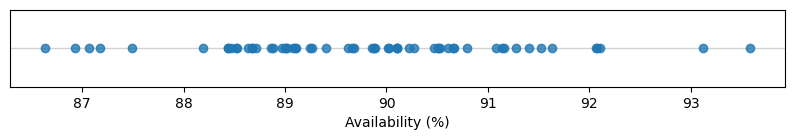

In [169]:


y_zero = [0] * len(availability)

plt.figure(figsize=(10, 1))
plt.axhline(0, linewidth=1, color="lightgrey", zorder=0)
plt.scatter(availability, y_zero, alpha=0.8)

fn = lambda x, pos: f"{format_percent_half_up(x, "0")}"
plt.gca().xaxis.set_major_formatter(FuncFormatter(fn))

# Axis formatting
plt.xlabel("Availability (%)")
plt.yticks([])  # hide meaningless Y-axis

plt.savefig(f"{PATH}/eda-individual-value-plot.png", dpi=300,
    bbox_inches="tight",
    pad_inches=0.1)

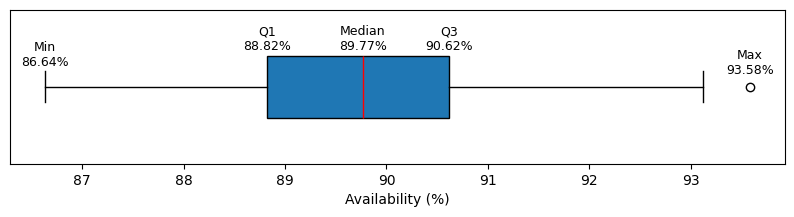

In [170]:
availability = np.array(availability)

# ---- Compute statistics ----
q1 = np.percentile(availability, 25)
median = np.percentile(availability, 50)
q3 = np.percentile(availability, 75)
min_val = availability.min()
max_val = availability.max()

plt.figure(figsize=(10, 2))

plt.boxplot(
    availability,
    vert=False,
    widths=0.4,
    showfliers=True,
    medianprops=dict(color="red", linewidth=1),
    boxprops=dict(linewidth=1, facecolor="#1f77b4", edgecolor="black"),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
    patch_artist=True
)

# X-axis: integer percentages
plt.gca().xaxis.set_major_locator(MultipleLocator(0.01))

def percent_integer(x, pos):
    return f"{int(round(x * 100))}"

plt.gca().xaxis.set_major_formatter(FuncFormatter(percent_integer))

# Axis formatting
plt.xlabel("Availability (%)")
plt.yticks([])

stats = {
    "Min": min_val,
    "Q1": q1,
    "Median": median,
    "Q3": q3,
    "Max": max_val,
}

for label, x in stats.items():
    # plt.axvline(x, linestyle="--", linewidth=1, alpha=0.7)
    y = 1.4
    if label in ("Min",):
        y = 1.3
    elif label in ("Max"):
        y = 1.25
    plt.text(
        x,
        y,
        f"{label}\n{format_percent_half_up(x)}%",
        ha="center",
        va="top",
        fontsize=9
    )

plt.savefig(
    f"{PATH}/eda-box-plot.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1
)

plt.savefig(f"{PATH}/eda-box-plot.png", dpi=300)

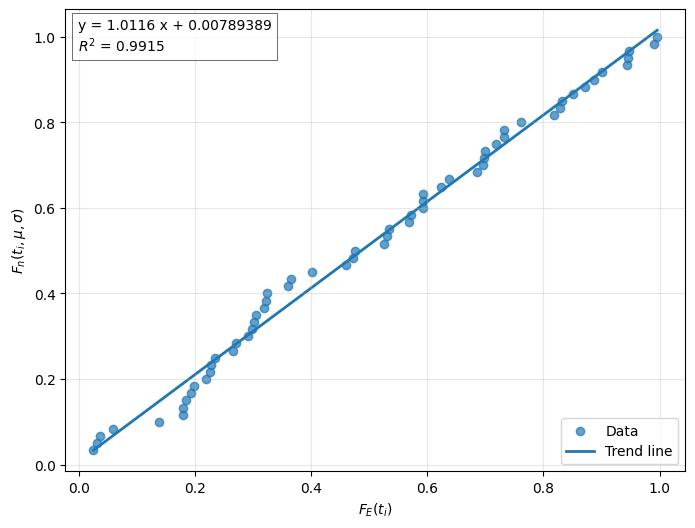

In [181]:

# Path to CSV
csv_path = "/home/vinesnts/Projetos/Midd4VC/experiments/ppplot.csv"

# Load CSV
df = pd.read_csv(csv_path)

# Pick first two numeric columns (x, y)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) < 2:
    raise ValueError(f"Expected at least two numeric columns in {csv_path}, found: {num_cols}")

x_col, y_col = num_cols[1], num_cols[0]
x = df[x_col].to_numpy(dtype=float)
y = df[y_col].to_numpy(dtype=float)

# Filter NaNs / infs
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# Linear fit (degree 1)
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

# Coefficient of determination R^2
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot != 0 else float("nan")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, label="Data")
x_line = np.linspace(np.min(x), np.max(x), 200)
plt.plot(x_line, slope * x_line + intercept, color="#1f77b4", linewidth=2, label="Trend line", zorder=0)

plt.xlabel("$F_E (t_i)$")
plt.ylabel("$F_n (t_i,\\mu,\\sigma)$")

# Equation and R^2 annotation
eq_text = f"y = {slope:.6g} x + {intercept:.6g}\n$R^2$ = {r2:.4f}"
plt.gca().text(
    0.02, 0.98, eq_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="black", linewidth=0.5)
)

plt.legend()
plt.grid(alpha=0.3)

# Save figure
plt.savefig(f"{PATH}/ppplot-scatter-trendline.png", dpi=300, bbox_inches="tight")
plt.show()